In [1]:
import pandas as pd
import numpy as np

In [2]:
traffic_df = pd.read_csv('smart_mobility_dataset.csv')

In [3]:
traffic_df.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,High
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,High
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,High
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,High
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Low


In [4]:
traffic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               5000 non-null   object 
 1   Latitude                5000 non-null   float64
 2   Longitude               5000 non-null   float64
 3   Vehicle_Count           5000 non-null   int64  
 4   Traffic_Speed_kmh       5000 non-null   float64
 5   Road_Occupancy_%        5000 non-null   float64
 6   Traffic_Light_State     5000 non-null   object 
 7   Weather_Condition       5000 non-null   object 
 8   Accident_Report         5000 non-null   int64  
 9   Sentiment_Score         5000 non-null   float64
 10  Ride_Sharing_Demand     5000 non-null   int64  
 11  Parking_Availability    5000 non-null   int64  
 12  Emission_Levels_g_km    5000 non-null   float64
 13  Energy_Consumption_L_h  5000 non-null   float64
 14  Traffic_Condition       5000 non-null   

In [5]:
for col in traffic_df.columns:
    print(f'{col}: {len(traffic_df[col].unique())}')

Timestamp: 5000
Latitude: 5000
Longitude: 5000
Vehicle_Count: 290
Traffic_Speed_kmh: 5000
Road_Occupancy_%: 5000
Traffic_Light_State: 3
Weather_Condition: 4
Accident_Report: 2
Sentiment_Score: 5000
Ride_Sharing_Demand: 99
Parking_Availability: 50
Emission_Levels_g_km: 5000
Energy_Consumption_L_h: 5000
Traffic_Condition: 3


In [6]:
print(traffic_df['Traffic_Light_State'].unique())
print(traffic_df['Weather_Condition'].unique())
print(traffic_df['Traffic_Condition'].unique())

['Yellow' 'Green' 'Red']
['Clear' 'Rain' 'Fog' 'Snow']
['High' 'Low' 'Medium']


In [7]:
TLS_Map = {'Green': 0, 'Yellow': 1, 'Red': 2}
WC_Map = {'Clear': 0, 'Rain': 1, 'Fog': 2, 'Snow': 3}
TC_Map = {'Low': 0, 'Medium': 1, 'High': 2}

In [8]:
df_f = traffic_df.drop(['Timestamp'], axis=1)
df_f['Traffic_Light_State'] = df_f['Traffic_Light_State'].map(TLS_Map)
df_f['Weather_Condition'] = df_f['Weather_Condition'].map(WC_Map)
df_f['Traffic_Condition'] = df_f['Traffic_Condition'].map(TC_Map)

print(df_f['Traffic_Light_State'].unique())
print(df_f['Weather_Condition'].unique())
print(df_f['Traffic_Condition'].unique())

[1 0 2]
[0 1 2 3]
[2 0 1]


In [9]:
df_f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Latitude                5000 non-null   float64
 1   Longitude               5000 non-null   float64
 2   Vehicle_Count           5000 non-null   int64  
 3   Traffic_Speed_kmh       5000 non-null   float64
 4   Road_Occupancy_%        5000 non-null   float64
 5   Traffic_Light_State     5000 non-null   int64  
 6   Weather_Condition       5000 non-null   int64  
 7   Accident_Report         5000 non-null   int64  
 8   Sentiment_Score         5000 non-null   float64
 9   Ride_Sharing_Demand     5000 non-null   int64  
 10  Parking_Availability    5000 non-null   int64  
 11  Emission_Levels_g_km    5000 non-null   float64
 12  Energy_Consumption_L_h  5000 non-null   float64
 13  Traffic_Condition       5000 non-null   int64  
dtypes: float64(7), int64(7)
memory usage: 54

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
from matplotlib import rcParams
rcParams['figure.figsize'] = 15, 5
sns.set_style('darkgrid')

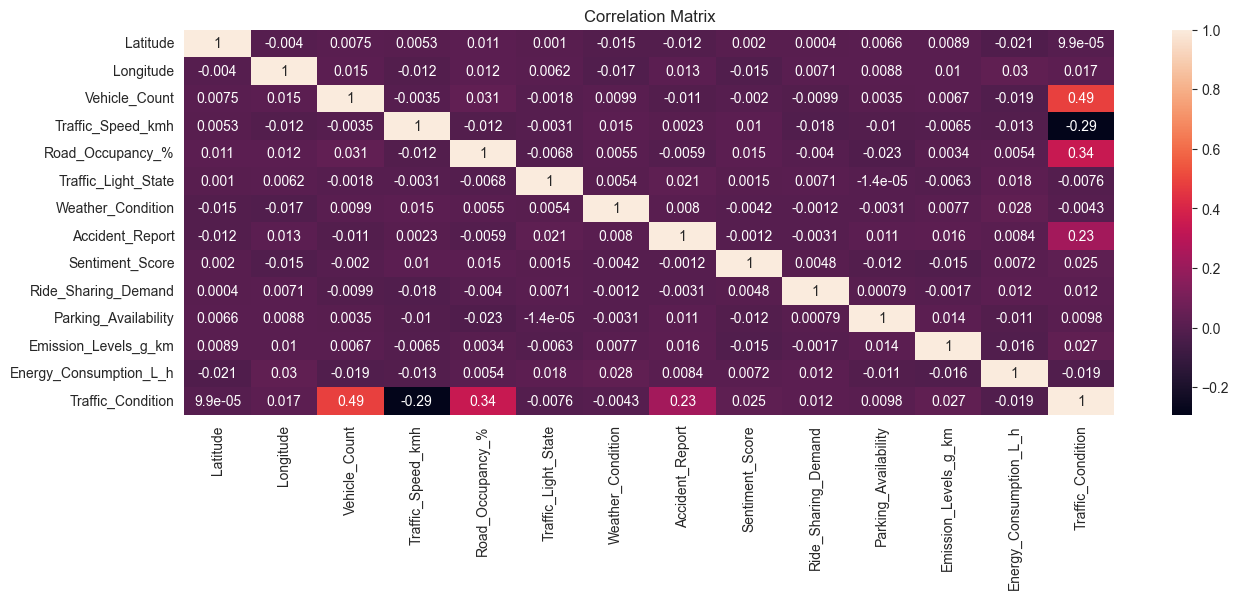

In [24]:
sns.heatmap(df_f.corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()

In [32]:
X = df_f[[
    'Vehicle_Count',
    'Traffic_Speed_kmh',
    'Road_Occupancy_%',
    'Traffic_Light_State',
    'Accident_Report'
]].copy()

y = df_f['Traffic_Condition']

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=0
)

In [75]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128,64,32,16),
    max_iter=500,
    activation='relu',
    random_state=0
)

mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(128, 64, 32, 16), max_iter=500,
              random_state=0)

In [77]:
predictions = mlp.predict(X_test)

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       107
           1       0.96      0.98      0.97       441
           2       1.00      0.99      0.99       952

    accuracy                           0.98      1500
   macro avg       0.97      0.98      0.98      1500
weighted avg       0.98      0.98      0.98      1500



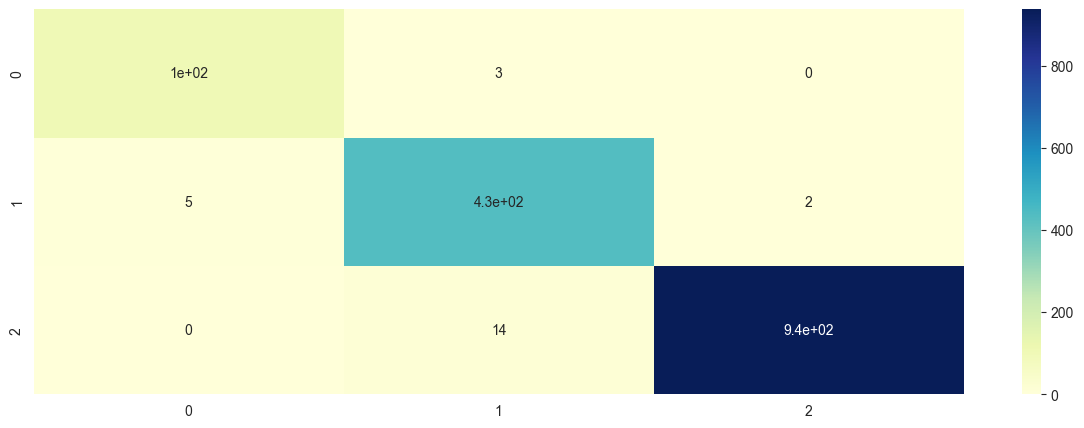

In [79]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test,predictions))
sns.heatmap(confusion_matrix(y_test,predictions), cmap='YlGnBu', annot=True)
plt.show()